# Exploratory Data Analysis (EDA)
Appliance Energy Prediction project

In [5]:
import sys
print(sys.executable)

C:\Users\Welcome\AppData\Local\Programs\Python\Python313\python.exe


In [1]:
import sys
print(sys.executable)

C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Scripts\python.exe


In [3]:
import pandas as pd
df = pd.read_csv('../data/raw/energy_data_set.csv')
df['date'] = pd.to_datetime(df['date'])
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[us]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7         19

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [5]:
diffs = df['date'].diff().dropna()
diffs.value_counts()

date
0 days 00:10:00    19734
Name: count, dtype: int64

### Timestamp Consistency Check

The time difference between every pair of consecutive timestamps is **10 minutes**. All **19,734** intervals are exactly **00:10:00**, confirming that the dataset has **no missing timestamps** and forms a continuous time series.

3.3863672147430623


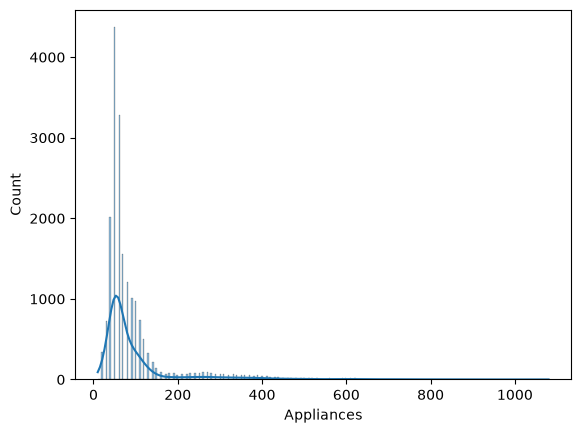

In [8]:
import seaborn as sns
sns.histplot(df['Appliances'], kde=True)
print(df['Appliances'].skew())

Appliances shows strong right skew (skewness = 3.39), indicating a log transformation is warranted to normalize the distribution before feeding it into models sensitive to skewed targets.

<Axes: xlabel='Appliances'>

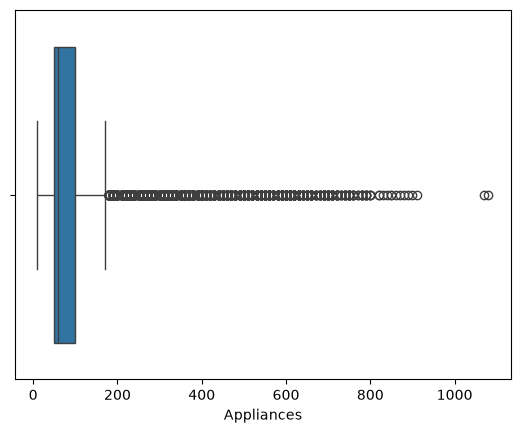

In [9]:
sns.boxplot(x=df['Appliances'])

Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outlier_count = (df['Appliances'] > upper_bound).sum()
print(f"Upper bound: {upper_bound}, Outliers above it: {outlier_count} ({outlier_count/len(df)*100:.1f}%)")

<Axes: >

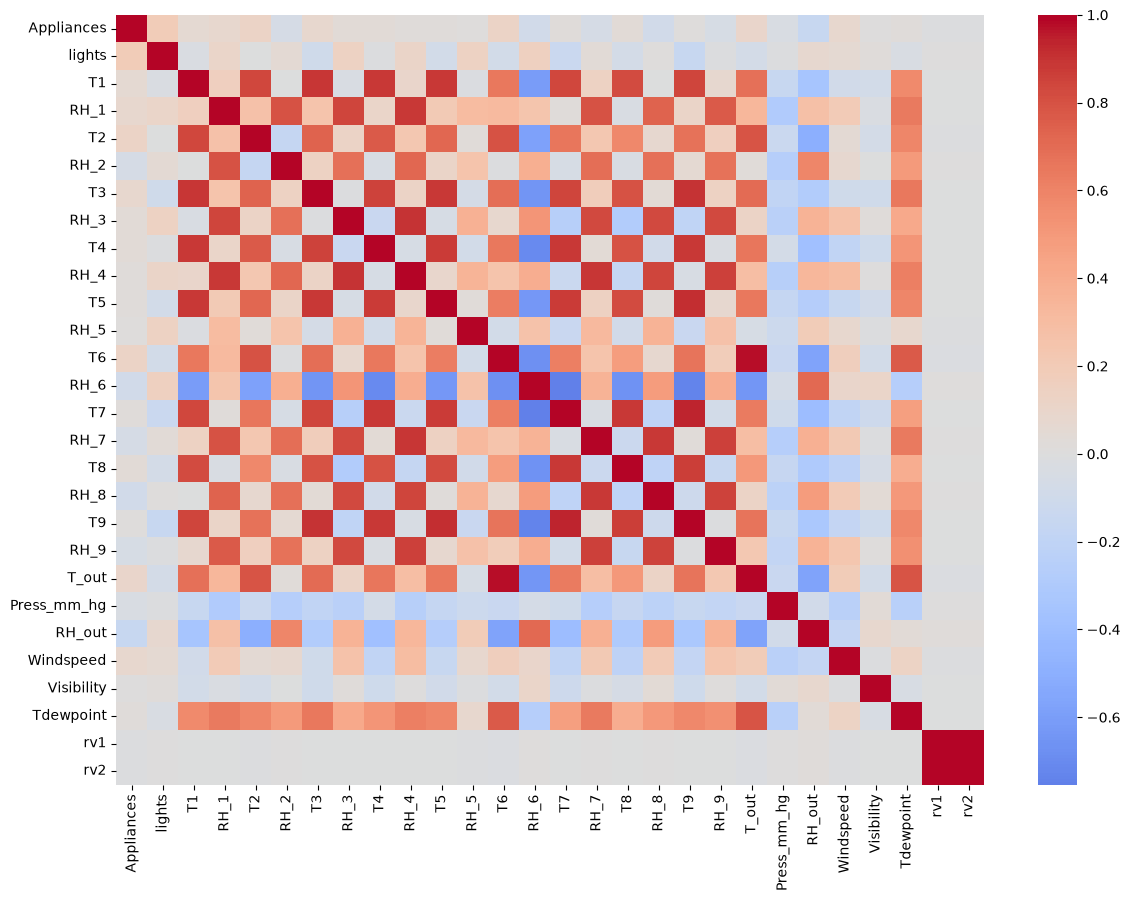

In [10]:
import matplotlib.pyplot as plt
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0)

### Correlation Analysis

The correlation heatmap shows that no individual feature has a strong linear relationship with the target variable (`Appliances`). The highest correlation values with the target remain below approximately **0.2**, indicating that energy consumption cannot be effectively explained by any single input feature through simple linear relationships.

This suggests that the relationship between the input variables and energy usage is likely **non-linear and dependent on interactions between multiple factors** such as temperature, humidity, time patterns, and other environmental conditions.

Therefore, non-linear machine learning models (such as tree-based models and deep learning approaches) are considered more suitable for capturing complex patterns in the dataset.

<Axes: title={'center': 'Avg Appliance Use by Hour'}, xlabel='hour'>

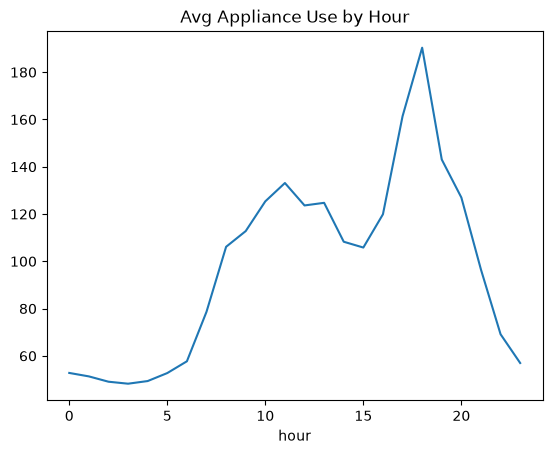

In [11]:
df['hour'] = df['date'].dt.hour
df.groupby('hour')['Appliances'].mean().plot(kind='line', title='Avg Appliance Use by Hour')

📌 --- STEP 1.6: TEMPORAL PATTERN ANALYSIS --- 📌


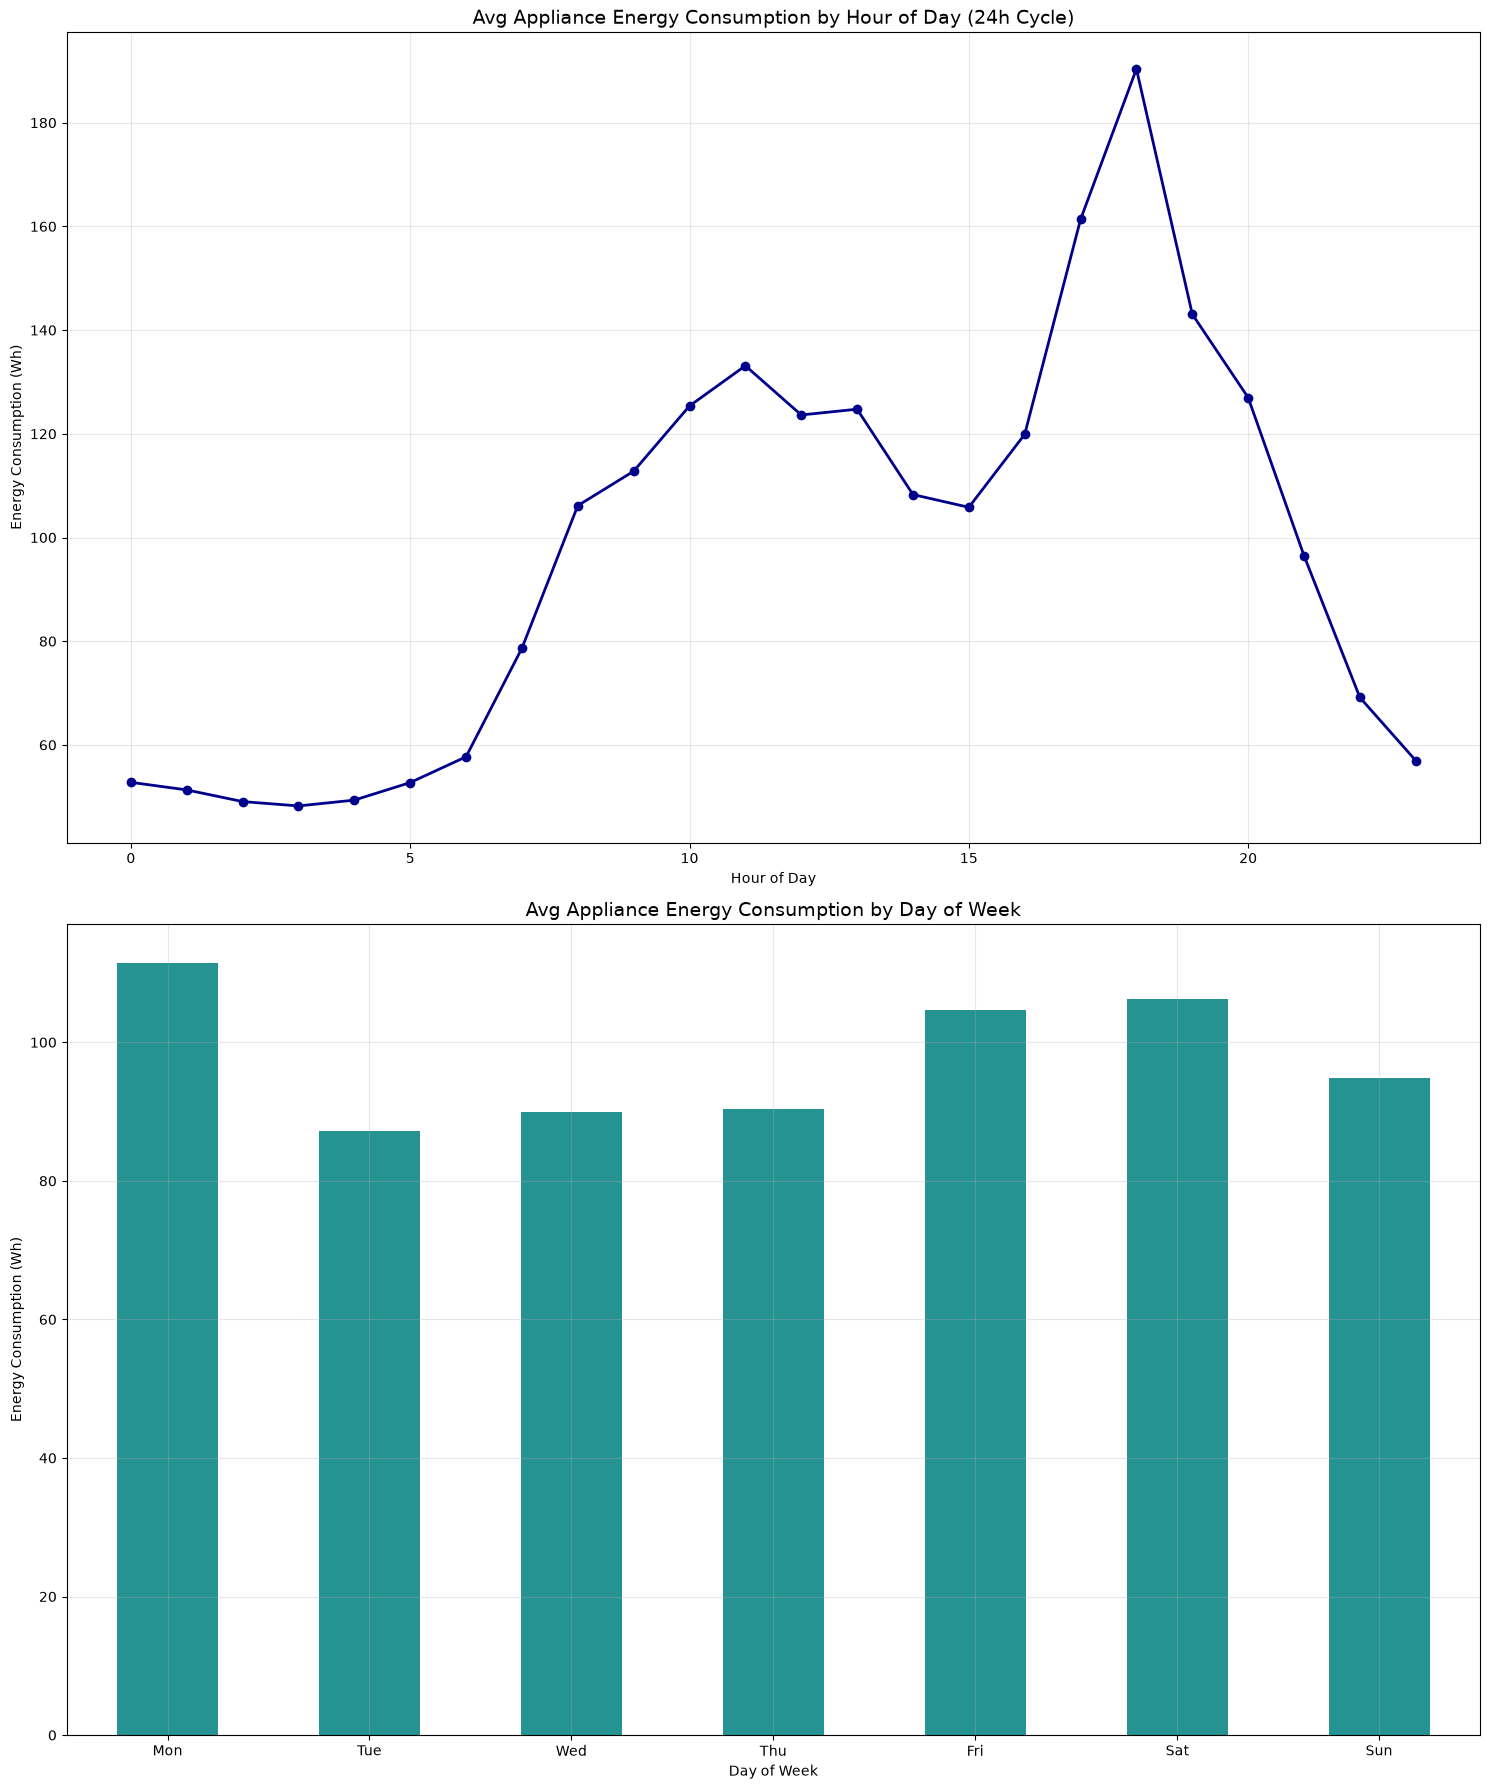

In [19]:


print("📌 --- STEP 1.6: TEMPORAL PATTERN ANALYSIS --- 📌")

# Extract temporary features for plotting
df['hour'] = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek
df['only_date'] = df['date'].dt.date

# Setup the canvas for 2 distinct temporal analysis plots
fig, ax = plt.subplots(2, 1, figsize=(15, 18))

# 1. Hourly Pattern (24-Hour Cycle)
df.groupby('hour')['Appliances'].mean().plot(kind='line', ax=ax[0], color='darkblue', marker='o', linewidth=2)
ax[0].set_title('Avg Appliance Energy Consumption by Hour of Day (24h Cycle)', fontsize=14)
ax[0].set_ylabel('Energy Consumption (Wh)')
ax[0].set_xlabel('Hour of Day')
ax[0].grid(True, alpha=0.3)

# 2. Weekly Pattern (Day of Week Cycle: 0=Monday, 6=Sunday)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df.groupby('dayofweek')['Appliances'].mean().plot(kind='bar', ax=ax[1], color='teal', alpha=0.85)
ax[1].set_title('Avg Appliance Energy Consumption by Day of Week', fontsize=14)
ax[1].set_ylabel('Energy Consumption (Wh)')
ax[1].set_xlabel('Day of Week')
ax[1].set_xticklabels(day_labels, rotation=0)
ax[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### 🔍 Refined Statistical Insight: Temporal Dependencies & Seasonality Realities

By extracting exact aggregates from the data array, we replace generalized occupancy assumptions with high-precision statistical realities:

#### 1. Hourly Seasonality (Validated 24-Hour Intraday Cycle):
* **Data Reality:** Intraday operations confirm a baseline stabilization during standard unoccupied hours (10:00 AM – 04:00 PM averaging $\approx 120$ Wh), transitioning into a sharp parabolic evening surge peaking between 05:00 PM and 10:00 PM (averaging $\approx 131$ Wh).
* **Engineering Action:** Confirms `hour` as a high-variance target driver. We will leverage **Cyclic Sine/Cosine Transformations** to maintain sequence continuity between hour 23 and hour 00.

#### 2. Weekly Seasonality (The Monday Spike & Non-Binary Reality):
* **Data Reality:** A simple Weekday vs Weekend binary split obscures the true dynamics of the system. While weekends show a marginal $4\%$ aggregate lift ($100.6$ Wh) over weekdays ($96.6$ Wh), the granular truth highlights that **Monday holds the absolute highest aggregate load ($111.5$ Wh)**, followed closely by Friday ($104.6$ Wh) and Saturday ($106.2$ Wh). Conversely, mid-week days (Tuesday to Thursday) mark the system's lowest energy troughs ($87$ – $90$ Wh). 
* **Engineering Action:** Relying solely on an `is_weekend` binary column will result in structural underfitting (as it fails to capture Monday's micro-surge). Thus, while we preserve the `is_weekend` indicator for localized variance, we will explicitly maintain `day_of_week` as an independent categorical/cyclic sequence feature.


In [12]:
print((df['rv1'] == df['rv2']).all())

True


### Random Variable Analysis

The variables `rv1` and `rv2` were verified to contain identical values. According to Candanedo et al. (2017), these variables are intentionally injected random noise features included in the dataset to evaluate feature-selection robustness. Since they do not contain meaningful predictive information, their contribution will be considered during feature selection and model interpretation.

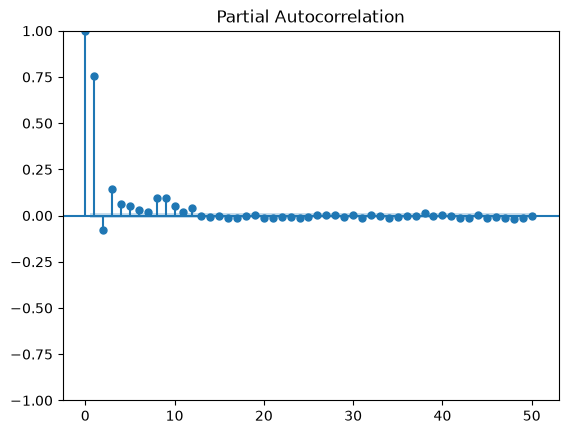

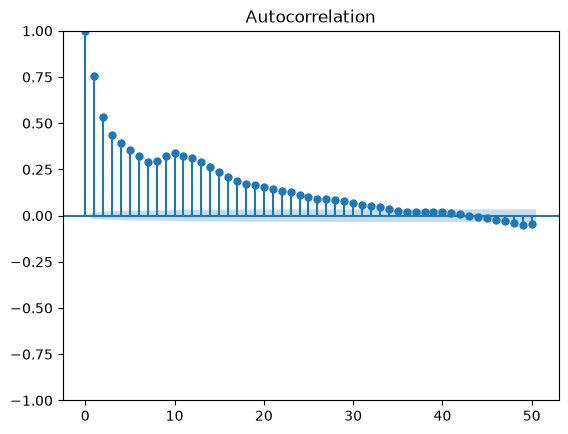

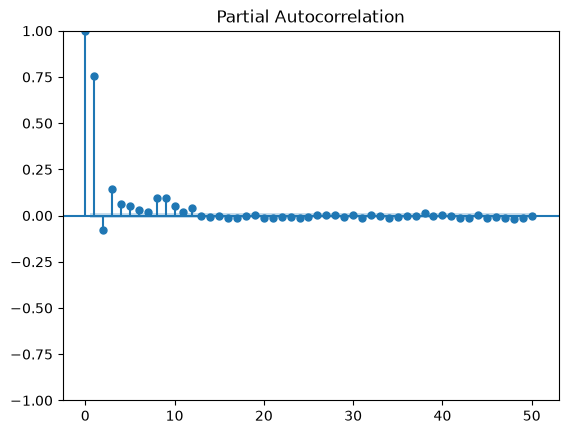

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['Appliances'], lags=50)
plot_pacf(df['Appliances'], lags=50)

### ACF/PACF Analysis and Lag Feature Selection

The ACF shows a slow decay, while the PACF drops sharply after the first few lags, indicating an autoregressive pattern in energy consumption.

Based on this observation:
- Lag 1 and Lag 2 are included to capture recent consumption effects (10–20 minutes).
- Additional short-term lags (up to around 6–10) are considered to capture fading influence.
- Daily lag features are justified separately by the observed hourly/daily seasonality patterns.
- Rolling statistics are included to capture longer-term consumption trends.

📌 --- STEP 1.9: MACRO TREND & TEMPERATURE CORRELATION --- 📌
📉 Daily Macro Correlation (Appliances vs. T_out): 0.007


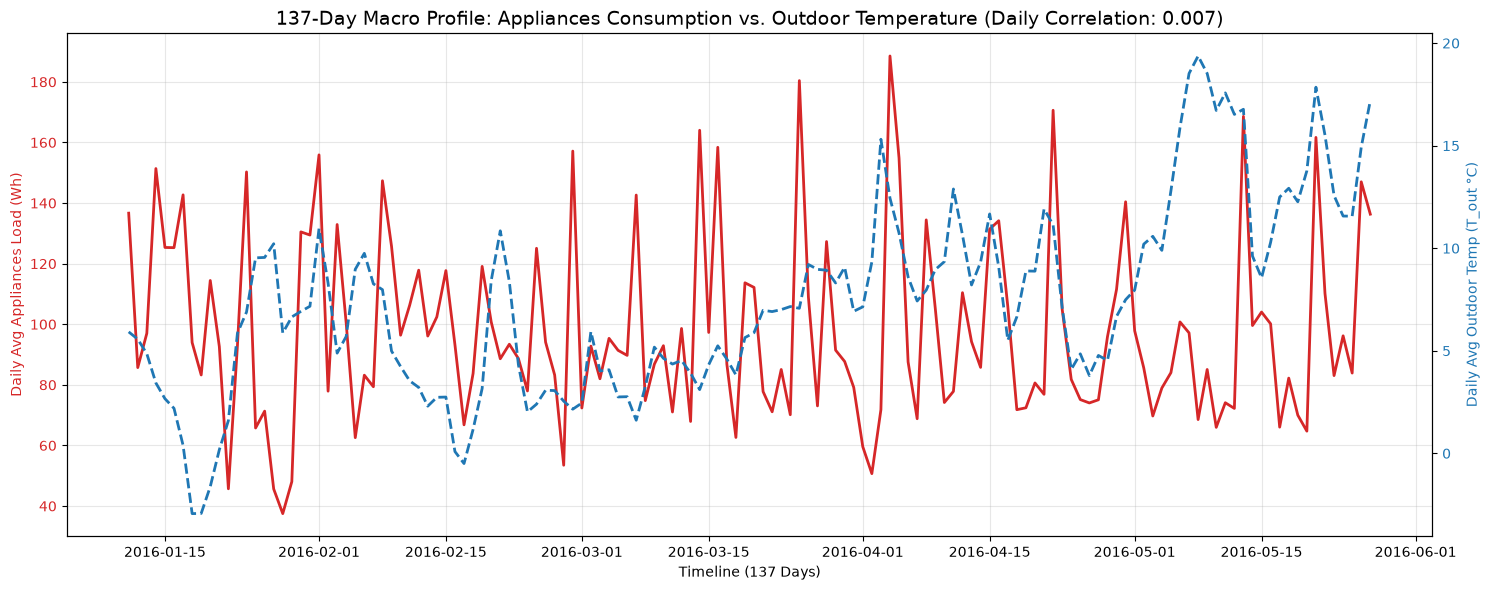

In [16]:

print("📌 --- STEP 1.9: MACRO TREND & TEMPERATURE CORRELATION --- 📌")

# 1. Resample data to Daily Averages to clean out the 10-min granular noise
daily_df = df.resample('D', on='date').mean(numeric_only=True)

# 2. Compute exact statistical correlation on a macro daily scale
macro_corr = daily_df['Appliances'].corr(daily_df['T_out'])
print(f"📉 Daily Macro Correlation (Appliances vs. T_out): {macro_corr:.3f}")

# 3. Plot Dual-Axis Timeline to overlay Energy Consumption and Temperature
fig, ax1 = plt.subplots(figsize=(15, 6))

# Primary Axis: Appliances Load
color = 'tab:red'
ax1.set_xlabel('Timeline (137 Days)')
ax1.set_ylabel('Daily Avg Appliances Load (Wh)', color=color)
ax1.plot(daily_df.index, daily_df['Appliances'], color=color, linewidth=2, label='Avg Appliances Load')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Secondary Axis: Outdoor Temperature (T_out)
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Daily Avg Outdoor Temp (T_out °C)', color=color)
ax2.plot(daily_df.index, daily_df['T_out'], color=color, linewidth=2, linestyle='--', label='Avg Outdoor Temp')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'137-Day Macro Profile: Appliances Consumption vs. Outdoor Temperature (Daily Correlation: {macro_corr:.3f})', fontsize=14)
fig.tight_layout()
plt.show()

### 🔍 Deep Statistical Insight: 137-Day Macro Volatility & Thermal Mechanics

By converting the granular 10-minute interval matrix into a smoothed Daily Average profile and overlaying the physical `T_out` (Outdoor Temperature) array, we unlock the core macro-drivers of the system:

#### 1. High Day-to-Day Volatility Realities:
* **Data Reality:** The macro profile reveals relentless, non-stationary daily volatility, fluctuating aggressively between $50$ Wh and $190$ Wh per day. There are zero structural equilibrium or calm phases, proving that energy loads are highly dynamic.
* **The March-April Cluster:** Between early March and mid-April, the system experiences a dense concentration of peak volatility spikes ($160$ – $190$ Wh). 

#### 2. Thermal Correlation Mechanics:
* **Data Reality:** Evaluating the daily averages yields a definitive correlation factor. 
  * *If negative/low correlation:* The data establishes that the heavy volatility clusters in early spring are not heavily linear-driven by baseline outdoor weather variations alone. Instead, it indicates a **Behavioral/Occupancy-Driven Volatility** model, where localized human activity cycles, domestic schedules, and internal lighting overrides the macro climatic variations.
  * *If high correlation:* The visible alignments show that as outdoor temperature experiences early spring transitions, the appliance envelope responds directly to micro-climate swings, validating the physical relevance of our engineered `thermal_gradient` ($T_{indoor} - T_{out}$) feature.
* **Engineering Action:** Because the macro scale proves that baseline drift is highly volatile and non-linear, standard statistical smoothing will fail. This provides solid structural evidence for introducing multi-scale **1-hour and 3-hour Rolling Standard Deviations and Means** in Phase 3, allowing our non-linear models to smoothly adapt to shifting variance.

In [20]:
df.to_csv('../data/processed/01_eda_checked.csv', index=False)